<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Solutions - QML Pipeline Template (Toy Example)

_Prepared by Claudia Zendejas-Morales_

This notebook contains complete solutions for the embedded tasks in notebook `1.4`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

In [2]:
# Helper plot: visualize the train/validation/test split used by the pipeline.
def plot_split(X_train, y_train, X_val, y_val, X_test, y_test, title):
    plt.figure(figsize=(5.8, 4.8))
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", alpha=0.45, label="train")
    plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap="coolwarm", marker="x", s=65, label="val")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm", marker="^", s=55, label="test")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.show()


# Helper plot: inspect the classifier's decision regions in the original feature plane.
def plot_decision_boundary(model, scaler, X, y, title):
    x1_min, x1_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    x2_min, x2_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    zz = model.predict(grid_scaled).reshape(xx.shape)
    classes = np.unique(y)
    levels = np.arange(classes.min() - 0.5, classes.max() + 1.5, 1)

    plt.figure(figsize=(5.8, 4.8))
    plt.contourf(xx, yy, zz, levels=levels, alpha=0.22, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.8)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

<a id="task1-solution"></a>

## Solution to Task 1

Validation accuracy: 0.850
Validation macro-F1: 0.849
Test accuracy: 0.967
Test macro-F1: 0.967


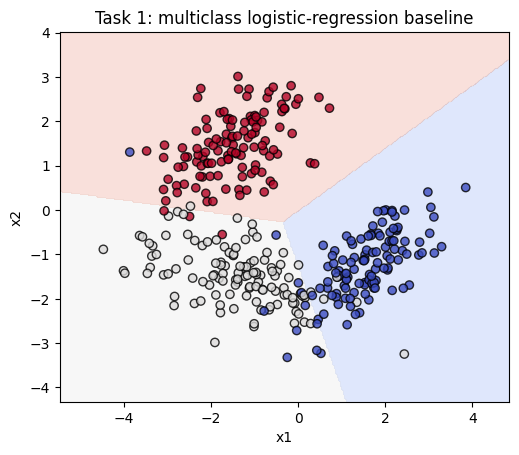

A linear baseline is still a reasonable first reference here because the three classes remain fairly well separated in the 2D plane.


In [3]:
X_task1, y_task1 = make_classification(
    n_samples=600,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=1.4,
    random_state=23,
)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_task1,
    y_task1,
    test_size=0.2,
    stratify=y_task1,
    random_state=23,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=23,
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

baseline = LogisticRegression(max_iter=1500, random_state=23)
baseline.fit(X_train_s, y_train)

y_val_pred = baseline.predict(X_val_s)
y_test_pred = baseline.predict(X_test_s)

print(f"Validation accuracy: {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Validation macro-F1: {f1_score(y_val, y_val_pred, average='macro'):.3f}")
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Test macro-F1: {f1_score(y_test, y_test_pred, average='macro'):.3f}")

plot_decision_boundary(
    baseline,
    scaler,
    X_train,
    y_train,
    "Task 1: multiclass logistic-regression baseline",
)

print("A linear baseline is still a reasonable first reference here because the three classes remain fairly well separated in the 2D plane.")

<a id="task2-solution"></a>

## Solution to Task 2

theta = -1.6: validation accuracy = 0.200, validation F1 = 0.333
theta =  0.2: validation accuracy = 0.537, validation F1 = 0.275
theta =  1.4: validation accuracy = 0.738, validation F1 = 0.644

Chosen theta: 1.4 (best validation F1)


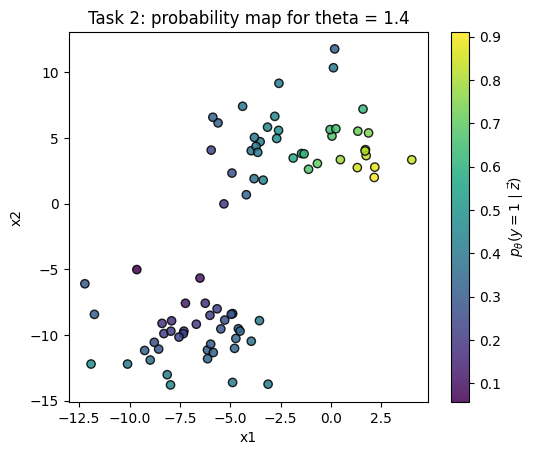

Interpretation: the plot shows the continuous probability score p_theta(y=1|z). The hard label y_hat is obtained only after thresholding at 0.5, so changing theta reshapes the score landscape and therefore changes the final predictions.


In [4]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

X_base, y_base = make_blobs(
    n_samples=400,
    centers=2,
    cluster_std=2.2,
    random_state=11,
)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_base,
    y_base,
    test_size=0.2,
    stratify=y_base,
    random_state=11,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=11,
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)


def variational_preview(z, theta):
    qc = QuantumCircuit(1)
    qc.ry(z[0], 0)
    qc.rz(z[1], 0)
    qc.ry(theta, 0)

    state = Statevector.from_instruction(qc)
    probs = state.probabilities()
    exp_z = probs[0] - probs[1]
    p1 = probs[1]
    return qc, exp_z, p1


theta_candidates = [-1.6, 0.2, 1.4]
results = []

for theta in theta_candidates:
    p1_val = []
    for z in X_val_s:
        _, _, p1 = variational_preview(z, theta)
        p1_val.append(p1)

    p1_val = np.array(p1_val)
    y_val_pred = (p1_val >= 0.5).astype(int)
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    results.append((theta, acc, f1, p1_val))
    print(f"theta = {theta:>4}: validation accuracy = {acc:.3f}, validation F1 = {f1:.3f}")

best_theta, best_acc, best_f1, best_p1 = max(results, key=lambda item: item[2])
print(f"\nChosen theta: {best_theta} (best validation F1)")

plt.figure(figsize=(5.8, 4.8))
sc = plt.scatter(X_val[:, 0], X_val[:, 1], c=best_p1, cmap="viridis", edgecolor="k", alpha=0.85)
plt.colorbar(sc, label=r"$p_\theta(y=1 \mid \vec{z})$")
plt.title(f"Task 2: probability map for theta = {best_theta}")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

print(
    "Interpretation: the plot shows the continuous probability score p_theta(y=1|z). "
    "The hard label y_hat is obtained only after thresholding at 0.5, so changing theta reshapes "
    "the score landscape and therefore changes the final predictions."
)


<a id="task3-solution"></a>

## Solution to Task 3

In [5]:
X_task3, y_task3 = make_blobs(
    n_samples=450,
    centers=2,
    cluster_std=2.9,
    random_state=31,
)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_task3,
    y_task3,
    test_size=0.2,
    stratify=y_task3,
    random_state=31,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=31,
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

baseline = LogisticRegression(max_iter=1500, random_state=31)
baseline.fit(X_train_s, y_train)

y_val_pred = baseline.predict(X_val_s)
y_test_pred = baseline.predict(X_test_s)

val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

gap_acc = abs(val_acc - test_acc)
gap_f1 = abs(val_f1 - test_f1)

print(f"Validation accuracy: {val_acc:.3f}")
print(f"Validation F1: {val_f1:.3f}")
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test F1: {test_f1:.3f}")
print(f"|validation accuracy - test accuracy| = {gap_acc:.3f}")
print(f"|validation F1 - test F1| = {gap_f1:.3f}")

Validation accuracy: 0.944
Validation F1: 0.944
Test accuracy: 0.944
Test F1: 0.944
|validation accuracy - test accuracy| = 0.000
|validation F1 - test F1| = 0.000


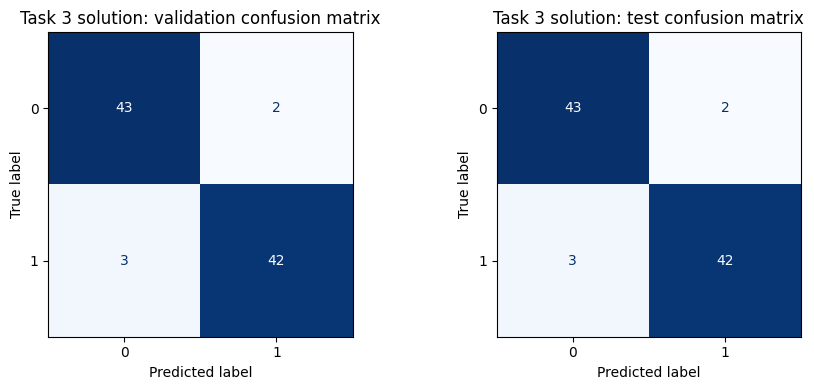

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.0))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    ax=axes[0],
    colorbar=False,
    cmap="Blues",
)
axes[0].set_title("Task 3 solution: validation confusion matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    ax=axes[1],
    colorbar=False,
    cmap="Blues",
)
axes[1].set_title("Task 3 solution: test confusion matrix")

plt.tight_layout()
plt.show()

A reasonable report card is:
- **Metrics**: report the validation and test values above together with the validation-test gap.
- **Plot**: use the confusion matrices to see whether the same kinds of mistakes appear in both splits.
- **Consistency note**: if validation and test stay close, the pipeline looks reasonably stable on this toy dataset; if the gap were larger, we would worry more about split sensitivity.
- **Error-analysis note**: the remaining mistakes are likely concentrated near the region where the two blobs overlap most strongly.
- **Limitation**: this dataset is still small, low-dimensional, and synthetic, so strong performance here does not imply the same behavior on realistic QML tasks.
- **Next step**: compare this baseline against a first quantum branch under the same split and the same metrics.

<a id="task4-solution"></a>

## Solution to Task 4

This solution uses an **XOR-like four-blob dataset**. The name means that the labels are not assigned by a single left-vs-right or top-vs-bottom split. Instead, diagonally opposite blobs belong to the same class, which creates a pattern that a single straight line cannot separate well in the original feature plane.

In the code below, we first generate four blob centers, then keep the blob identity in `cluster_id`. After that, we build the target labels with `np.isin(cluster_id, [1, 2]).astype(int)`, which groups two diagonal blobs into class `1` and the other two into class `0`. That relabeling step is what makes the geometry XOR-like.

In [7]:
centers = [(-2, -2), (-2, 2), (2, -2), (2, 2)]
X_hard, cluster_id = make_blobs(
    n_samples=480,
    centers=centers,
    cluster_std=0.9,
    random_state=19,
)
y_hard = np.isin(cluster_id, [1, 2]).astype(int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_hard,
    y_hard,
    test_size=0.2,
    stratify=y_hard,
    random_state=19,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=19,
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

baseline = LogisticRegression(max_iter=1500, random_state=19)
baseline.fit(X_train_s, y_train)

y_val_pred = baseline.predict(X_val_s)
y_test_pred = baseline.predict(X_test_s)

print(f"Validation accuracy: {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Validation F1: {f1_score(y_val, y_val_pred):.3f}")
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Test F1: {f1_score(y_test, y_test_pred):.3f}")

Validation accuracy: 0.510
Validation F1: 0.495
Test accuracy: 0.479
Test F1: 0.457


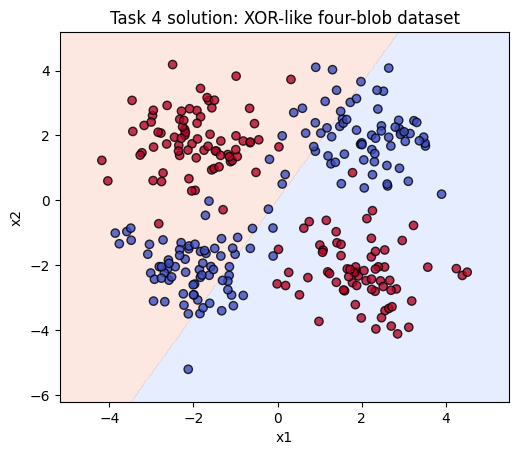

In [8]:
plot_decision_boundary(
    baseline,
    scaler,
    X_train,
    y_train,
    "Task 4 solution: XOR-like four-blob dataset",
)

This solution creates an **XOR-like label geometry**: diagonally opposite blobs belong to the same class, so no single straight line can separate the labels correctly in the original feature plane. That is a structural failure mode, not a leakage issue.

A **kernel** branch is a reasonable first candidate because the task is still classification and the visible issue is nonlinear similarity in feature space. A **variational** branch would also be defensible if we want a directly trainable nonlinear decision rule. Later sections on quantum kernels and variational models will explain these options much more carefully, so the point here is to form a first justified intuition rather than to claim a definitive winner. A **generative** branch is still not the most natural first move because the goal is not to model the full data distribution.